In [2]:

import pandas as pd
import json

# 1. 파일 불러오기 
file_path = '/Users/seojiho/Downloads/SSU_Datathon2025_공학분야_62199.json' 

with open(file_path, 'r', encoding='utf-8') as f:
    try:
        data = json.load(f)
    except ValueError:
        f.seek(0)
        data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

# 2. NODE_LIST 구조 파악
print("데이터 변환 중... 잠시만 기다려주세요.")

# 'NODE_LIST' 컬럼이 리스트를 포함하고 있다면 이를 행으로 확장
if 'NODE_LIST' in df.columns:
    # 리스트 안의 요소들을 개별 행으로 펼침
    exploded_df = df.explode('NODE_LIST')
    
    # 딕셔너리 형태의 데이터를 개별 컬럼으로 분리
    final_df = pd.json_normalize(exploded_df['NODE_LIST'])
    
    print("--- 변환 완료! ---")
    print(f"전체 논문 개수: {len(final_df)}개")
    print("\n--- 새로 생성된 컬럼(항목) 목록 ---")
    print(final_df.columns.tolist())
    
    print("\n--- 데이터 상단 5행 확인 ---")
    display(final_df.head())
else:
    print("NODE_LIST 컬럼을 찾을 수 없습니다. df.columns를 확인해보세요.")

# 1. NODE_LIST의 첫 번째 행에 정확히 뭐가 들어있는지 확인
print("--- 1. 데이터 타입 확인 ---")
sample = df['NODE_LIST'].iloc[0]
print(f"타입: {type(sample)}")

print("\n--- 2. 실제 내용물 출력 (앞부분 500자) ---")
print(str(sample)[:500])

# 2. 만약 리스트 안에 리스트가 또 들어있는 구조인지 확인
if isinstance(sample, list) and len(sample) > 0:
    print("\n--- 3. 리스트 내부의 첫 번째 요소 타입 ---")
    print(type(sample[0]))
    print("\n--- 4. 리스트 내부의 첫 번째 요소 내용 ---")
    print(sample[0])

데이터 변환 중... 잠시만 기다려주세요.
--- 변환 완료! ---
전체 논문 개수: 792176개

--- 새로 생성된 컬럼(항목) 목록 ---
[]

--- 데이터 상단 5행 확인 ---


""
0
1
2
3
4


--- 1. 데이터 타입 확인 ---
타입: <class 'dict'>

--- 2. 실제 내용물 출력 (앞부분 500자) ---
{'NODE_ID': 'NODE10561230', 'IPRD_NM': '제어로봇시스템학회', 'PLCT_NM': '제어로봇시스템학회 논문지', 'NODE_TTLE': '카테시안 공간에서 시간 지연제어기의 구현에 대한 튜토리얼', 'NODE_TTLE_EN': 'Tutorial on Implementation of Time-delayed Controllers in the Cartesian Space for Robot Manipulators', 'PBSH': '202106', 'NODE_LINK': 'https://www.dbpia.co.kr/journal/articleDetail?nodeId=NODE10561230', 'NODE_CLSS_01': '공학', 'NODE_CLSS_02': '전기전자공학', 'AUTR_NM': '정슬', 'KYWD': 'Robot control,robot manipulators,time-delayed control,Cartesian space control'


In [3]:
import pandas as pd

final_df = pd.DataFrame(df['NODE_LIST'].tolist())

# 결과 확인
print(f"전체 논문 개수: {len(final_df)}개")
print("\n--- 실제 분석에 사용할 항목(컬럼) 목록 ---")
print(final_df.columns.tolist())

# 코드 수행 예시 5개만 표현
display(final_df.head())

전체 논문 개수: 62199개

--- 실제 분석에 사용할 항목(컬럼) 목록 ---
['NODE_ID', 'IPRD_NM', 'PLCT_NM', 'NODE_TTLE', 'NODE_TTLE_EN', 'PBSH', 'NODE_LINK', 'NODE_CLSS_01', 'NODE_CLSS_02', 'AUTR_NM', 'KYWD', 'ABST_KR', 'ABST_EN']


,NODE_ID,IPRD_NM,PLCT_NM,NODE_TTLE,NODE_TTLE_EN,PBSH,NODE_LINK,NODE_CLSS_01,NODE_CLSS_02,AUTR_NM,KYWD,ABST_KR,ABST_EN
0,NODE10561230,제어로봇시스템학회,제어로봇시스템학회 논문지,카테시안 공간에서 시간 지연제어기의 구현에 대한 튜토리얼,Tutorial on Implementation of Time-delayed Con...,202106,https://www.dbpia.co.kr/journal/articleDetail?...,공학,전기전자공학,정슬,"Robot control,robot manipulators,time-delayed ...",,This paper presents a tutorial on the implemen...
1,NODE10561231,제어로봇시스템학회,제어로봇시스템학회 논문지,파이프 구조물 검사를 위한 파이프 등반 로봇의 위치 추적,Position Tracking of Pipe-Climbing Robot for P...,202106,https://www.dbpia.co.kr/journal/articleDetail?...,공학,전기전자공학,"이스라엘, 권영재, 이성욱, 김재희, 박종원","pipe-climbing,pipe climbing robot,location tra...",,In nuclear power plants and petrochemical plan...
2,NODE10561232,제어로봇시스템학회,제어로봇시스템학회 논문지,Depth와 Amplitude Image를 이용한 차량 문 주변 장애물 인식 및 거...,Obstacle Recognition and Distance Estimation n...,202106,https://www.dbpia.co.kr/journal/articleDetail?...,공학,전기전자공학,"홍순원, 이동현, 류춘우, 김학일","ToF (Time of Flight) camera,depth image,amplit...",,Vehicle-related accidents can occur not only w...
3,NODE10561237,제어로봇시스템학회,제어로봇시스템학회 논문지,단시간 푸리에 변환과 전역 통과 필터 기반 노치 필터를 이용한 다중 주파수 제거 기법,Multiple Frequency Rejection using Short-time ...,202106,https://www.dbpia.co.kr/journal/articleDetail?...,공학,전기전자공학,"차재혁, 김예준, 박찬국, 김광훈, 권승복","adaptive notch filter,time-frequency analysis,...",,This paper proposes a novel multiple frequency...
4,NODE10561238,제어로봇시스템학회,제어로봇시스템학회 논문지,MEMS/FOG 기반 관성항법장치 2단계 교정 방법 개발,Development of Two-Stage Calibration Technique...,202106,https://www.dbpia.co.kr/journal/articleDetail?...,공학,전기전자공학,"유해성, 서영빈, 이인섭, 오주현, 이형섭, 김천중, 이상정","MEMS/FOG,Inertial Navigation System,Two stage ...",,This paper presents a two-stage calibration me...


In [4]:
# 1. 전체 데이터(final_df)를 엑셀 파일로 저장

try:
    final_df.to_excel('all_papers_data.xlsx', index=False)
    print("성공! 전체 데이터가 'all_papers_data.xlsx' 파일로 저장되었습니다.")
except ModuleNotFoundError:
    # 엑셀 저장 라이브러리가 없을 경우 설치 후 재시도 안내
    print("에러: 'openpyxl' 라이브러리가 필요합니다. 아래 셀에 !pip install openpyxl 를 입력해 설치하세요.")
except Exception as e:
    # 데이터가 너무 커서 엑셀이 감당 못 할 경우 CSV로 저장 유도
    print(f"엑셀 저장 중 오류 발생: {e}")
    print("데이터가 너무 커서 오류가 날 수 있습니다. 대신 CSV 형식으로 저장합니다...")
    final_df.to_csv('all_papers_data.csv', index=False, encoding='utf-8-sig')
    print("성공! 'all_papers_data.csv' 파일로 저장되었습니다.")

엑셀 저장 중 오류 발생: 마하수 4  및 마하수 6  유동에서 자유 비행하는 구의 항력계수 측정 cannot be used in worksheets.
데이터가 너무 커서 오류가 날 수 있습니다. 대신 CSV 형식으로 저장합니다...
성공! 'all_papers_data.csv' 파일로 저장되었습니다.


In [5]:
# 1. 컬럼명 전체 확인
print("--- 컬럼 목록 ---")
print(final_df.columns.tolist())

# 2. 실제 데이터 2개만 자세히 보기 (필터링 기준을 잡기 위함)
print("\n--- 데이터 샘플 (2개) ---")
# 제목, 키워드, 초록 컬럼이 있다면 그 내용을 확인합니다.
sample_cols = [col for col in ['NODE_TTLE', 'KYWD', 'ABST_KR', 'NODE_CLSS_02'] if col in final_df.columns]
display(final_df[sample_cols].head(2))

# 3. 키워드(KYWD) 컬럼이 어떤 식으로 저장되어 있는지 확인 (리스트인지, 콤마로 구분된 문자열인지)
print("\n--- 키워드 저장 방식 확인 ---")
print(type(final_df['KYWD'].iloc[0]))
print(final_df['KYWD'].iloc[0])

--- 컬럼 목록 ---
['NODE_ID', 'IPRD_NM', 'PLCT_NM', 'NODE_TTLE', 'NODE_TTLE_EN', 'PBSH', 'NODE_LINK', 'NODE_CLSS_01', 'NODE_CLSS_02', 'AUTR_NM', 'KYWD', 'ABST_KR', 'ABST_EN']

--- 데이터 샘플 (2개) ---


,NODE_TTLE,KYWD,ABST_KR,NODE_CLSS_02
0,카테시안 공간에서 시간 지연제어기의 구현에 대한 튜토리얼,"Robot control,robot manipulators,time-delayed ...",,전기전자공학
1,파이프 구조물 검사를 위한 파이프 등반 로봇의 위치 추적,"pipe-climbing,pipe climbing robot,location tra...",,전기전자공학



--- 키워드 저장 방식 확인 ---
<class 'str'>
Robot control,robot manipulators,time-delayed control,Cartesian space control


In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. 필터링 키워드 대폭 확장 (개수를 늘리기 위해 일반적인 단어도 추가)
wider_keywords = [
    '반도체', 'semiconductor', '웨이퍼', 'wafer', '박막', 'film', 
    '증착', 'deposition', '식각', 'etching', '노광', 'lithography', 
    '패키징', 'packaging', '소자', 'device', '회로', 'circuit', 
    'HBM', 'DRAM', 'NAND', '메모리', 'memory', '팹', 'foundry',
    '공정', 'process', '설계', 'design', '전력', 'power', '통신', 'ic', 'vlsi'
]
pattern = '|'.join(wider_keywords)

# 전체 데이터(final_df)에서 다시 추출
semi_df = final_df[
    final_df['NODE_TTLE'].str.contains(pattern, case=False, na=False) |
    final_df['KYWD'].str.contains(pattern, case=False, na=False) |
    final_df['ABST_KR'].str.contains(pattern, case=False, na=False)
].copy()

# 2. AI 분석용 텍스트 준비
semi_df['text_for_ai'] = semi_df['NODE_TTLE'].fillna('') + " " + semi_df['KYWD'].fillna('')

# 3. 그룹 개수를 8개로 늘려 더 세밀하게 분류 
tfidf = TfidfVectorizer(max_features=2000, min_df=2)
tfidf_matrix = tfidf.fit_transform(semi_df['text_for_ai'])
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
semi_df['cluster_no'] = kmeans.fit_predict(tfidf_matrix)

# 4. 결과 출력
print(f"--- 확장 추출 완료: {len(semi_df)}개 ---")
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(8):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"\n[그룹 {i}] 대표 단어: {', '.join(top_words)}")

--- 확장 추출 완료: 34552개 ---

[그룹 0] 대표 단어: 연구, 위한, 관한, 이용한, 기반, 대한, 따른, 개발, 평가, 특성

[그룹 1] 대표 단어: of, and, the, on, for, in, analysis, study, using, based

[그룹 2] 대표 단어: 미치는, 영향, nursing, self, satisfaction, job, 간호대학생의, efficacy, 중심으로, students

[그룹 3] 대표 단어: system, 시스템, control, 제어, 위한, 연구, 기반, 개발, power, energy

[그룹 4] 대표 단어: 설계, 위한, design, 구현, 기반, 이용한, 시스템, 연구, 구조, antenna

[그룹 5] 대표 단어: ai, 인공지능, intelligence, artificial, 생성형, generative, 기반, 연구, 위한, education

[그룹 6] 대표 단어: learning, deep, 딥러닝, machine, 기반, network, neural, classification, 예측, detection

[그룹 7] 대표 단어: 분석, analysis, 따른, 특성, 연구, 활용한, data, 위한, 기반, 중심으로


In [7]:
# 1. 3만개 데이터(semi_df)의 키워드 빈도 분석
# 키워드 컬럼을 쪼개서 가장 많이 나오는 단어 100개를 뽑습니다.
top_100_keywords = semi_df['KYWD'].str.split(',').explode().str.strip().value_counts().head(100)

print("--- [검수 1] 전체 데이터 내 핵심 키워드 TOP 100 ---")
print(top_100_keywords.to_dict()) # 제가 보기 편하게 사전형으로 출력

# 2. '반도체'라는 단어는 없지만 '공정/기술' 단어로 포함된 논문 샘플 (불순물 체크용)
print("\n--- [검수 2] 비(非)반도체 단어로 필터링된 논문 샘플 ---")
# 제목에 '반도체'가 없는 논문들 중 10개를 뽑아 어떤 내용인지 봅니다.
non_semi_sample = semi_df[~semi_df['NODE_TTLE'].str.contains('반도체', na=False)].sample(10)
display(non_semi_sample[['NODE_TTLE', 'KYWD']])

# 3. 불순물 후보 단어 필터링 테스트
noise_words = ['간호', '교육', '교사', '학생', '보건', '심리', '경영', '정치', '사회', '복지']
noise_results = {}
for word in noise_words:
    count = semi_df['NODE_TTLE'].str.contains(word, na=False).sum()
    noise_results[word] = count

print("\n--- [검수 3] 제거 대상 후보군 분포 ---")
print(noise_results)

--- [검수 1] 전체 데이터 내 핵심 키워드 TOP 100 ---
{'Deep Learning': 569, '딥러닝': 468, 'Deep learning': 378, 'Machine Learning': 340, 'Artificial Intelligence': 328, '인공지능': 327, 'deep learning': 272, 'CNN': 202, 'Machine learning': 199, 'AI': 173, 'LSTM': 162, 'COVID-19': 159, 'IoT': 153, 'machine learning': 152, '머신러닝': 149, 'Digital Forensics': 130, 'Metaverse': 124, 'Optimization': 122, 'Blockchain': 114, 'Generative AI': 112, 'Artificial intelligence': 110, '기계학습': 108, 'Classification': 107, 'Topic Modeling': 107, 'Simulation': 105, 'Object Detection': 102, 'Big Data': 97, '디지털 포렌식': 93, 'Drone': 91, 'Numerical analysis': 91, 'Text Mining': 88, 'artificial intelligence': 88, 'Depression': 86, 'UAV': 82, 'Virtual Reality': 81, 'Reinforcement Learning': 81, 'Computational Fluid Dynamics(전산유체역학)': 81, '메타버스': 79, 'FPGA': 78, 'Nursing Students': 78, '가상현실': 77, 'Reliability': 74, 'Microstructure': 74, 'CFD': 73, 'Image processing': 71, 'Natural Language Processing': 70, '블록체인': 70, 'Computer Visi

,NODE_TTLE,KYWD
42064,메카넘휠 기반의 직렬 및 병렬 결합이 가능한 군집 수송 로봇,"Transprt Robot(수송 로봇),Serial and Parallel Conf..."
14146,kNN-LSTM을 이용한 시간별 일사량 예측 성능 개선에 관한 연구,"일사량,태양광 발전,장단기 메모리,대기청명도,Solar Radiation,Solar..."
52763,Bonding Characteristics of Solder and Sinter J...,"Active metal brazing,Active metal brazing (AMB..."
55965,Low-Dimensional Vector Representation Learning...,"Natural language processing,Natural language u..."
16028,분산전원 수용률 향상을 위한 전압 및 무효전력 제어 알고리즘,"Volt/Var Optimization,Distributed Generation,O..."
27680,Performance of alkaline impregnated biochar de...,"Adsorption,Alkali impregnation,Biochar,Hydroge..."
23218,인공지능 자세 진단 디지털 테라퓨틱스 시스템 구현,"인공지능,퍼지이론,자세진단,디지털 치료,영상처리,Artificial Intellig..."
43988,에틸렌 연료 초음속 연소기 모델에서 화염 안정 모드의 분류 및 예측,"Supersonic combustor,Flame stabilization mode,..."
31286,물류단지 균형 배치를 위한 조세제도 개선 연구,"balanced distribution,local government,local t..."
4962,천안지역 논에서 청보리 후작으로 사료용 벼 및 사료 피를 이용한 조사료 생산 작부체...,"Barnyard Millet,Double Cropping System,Forage ..."



--- [검수 3] 제거 대상 후보군 분포 ---
{'간호': 283, '교육': 479, '교사': 90, '학생': 388, '보건': 28, '심리': 100, '경영': 45, '정치': 17, '사회': 260, '복지': 59}


In [8]:
import pandas as pd

# 1. 긍정 키워드 (이 단어 중 하나는 반드시 있어야 함 - 반도체 핵심 도메인)
positive_tech = [
    '반도체', 'semiconductor', '웨이퍼', 'wafer', '박막', 'thin film', 'epitaxial',
    '증착', 'deposition', 'ald', 'cvd', 'pvd', '식각', 'etching', '노광', 'lithography', 
    '패키징', 'packaging', 'hbm', 'dram', 'nand', 'v-nand', 'sram', 'flash memory',
    '소자', 'transistor', '트랜지스터', 'mosfet', 'finfet', 'gaafet', 'igbt',
    '회로설계', 'circuit design', 'vlsi', 'cmos', 'asic', 'fpga', 'soc',
    '공정', 'fabrication', 'foundry', '팹', 'clean room', 'cmp', 'doping'
]

# 2. 부정 키워드 (이 단어가 있으면 반도체 논문이 아닐 확률이 매우 높음 - 노이즈 제거)

negative_noise = [
    '간호', 'nursing', 'depression', '심리', '우울', '환자', '의료', 'hospital',
    '교육', 'education', '학습자', '교사', '학생', 'school', 'curriculum',
    '사회', '복지', '경영', '정치', 'politics', 'social', 'welfare',
    '포렌식', 'forensics', '블록체인', 'blockchain', 'metaverse', '메타버스',
    '코로나', 'covid', '토픽모델링', 'topic modeling'
]

# 3. 필터링 함수 적용
def filter_semiconductor(row):
    # 제목과 키워드를 합쳐서 검사
    content = str(row['NODE_TTLE']).lower() + " " + str(row['KYWD']).lower()
    
    # 1) 부정 단어가 포함되어 있으면 탈락
    if any(noise in content for noise in negative_noise):
        return False
    
    # 2) 긍정 단어가 하나라도 포함되어 있어야 합격
    if any(tech in content for tech in positive_tech):
        return True
    
    return False

# 4. 필터링 실행
final_cleaned_df = semi_df[semi_df.apply(filter_semiconductor, axis=1)].copy()

# 5. 결과 확인
print(f"🎯 최종 정제 완료!")
print(f"기존 확장 데이터: {len(semi_df)}개")
print(f"불순물 제거 후 최종 데이터: {len(final_cleaned_df)}개")

# 6. 최종 파일 저장
final_cleaned_df.to_csv('final_semiconductor_tech_only.csv', index=False, encoding='utf-8-sig')
print("\n📂 'final_semiconductor_tech_only.csv' 저장이 완료되었습니다.")

🎯 최종 정제 완료!
기존 확장 데이터: 34552개
불순물 제거 후 최종 데이터: 2624개

📂 'final_semiconductor_tech_only.csv' 저장이 완료되었습니다.


In [9]:
## 공정 vs 회로 분류


import pandas as pd

# 1. 분야별 판별 키워드 정의
process_keywords = ['공정', '증착', '식각', '노광', '패키징', '웨이퍼', 'deposition', 'etching', 'lithography', 'packaging', 'cmp', 'ald', 'cvd', '박막', 'thin film']
circuit_keywords = ['회로', '설계', 'design', 'circuit', 'cmos', 'vlsi', 'asic', 'fpga', 'soc', 'layout', 'sram', 'dram', 'logic', 'gate']

def classify_track(row):
    content = str(row['NODE_TTLE']).lower() + " " + str(row['KYWD']).lower()
    
    is_process = any(word in content for word in process_keywords)
    is_circuit = any(word in content for word in circuit_keywords)
    
    if is_process and is_circuit: return '융합(공정+회로)'
    if is_process: return '공정'
    if is_circuit: return '회로'
    return '기타 소자/소재'

# 2. 분류 적용
final_cleaned_df['track'] = final_cleaned_df.apply(classify_track, axis=1)

# 3. 결과 확인
print("--- 팀별 배정 데이터 규모 ---")
print(final_cleaned_df['track'].value_counts())

# 4. 파일 저장 (팀별로 필터링해서 쓰기 위함)
final_cleaned_df.to_csv('semiconductor_team_data.csv', index=False, encoding='utf-8-sig')

--- 팀별 배정 데이터 규모 ---
track
공정           1193
회로            705
기타 소자/소재      569
융합(공정+회로)     157
Name: count, dtype: int64


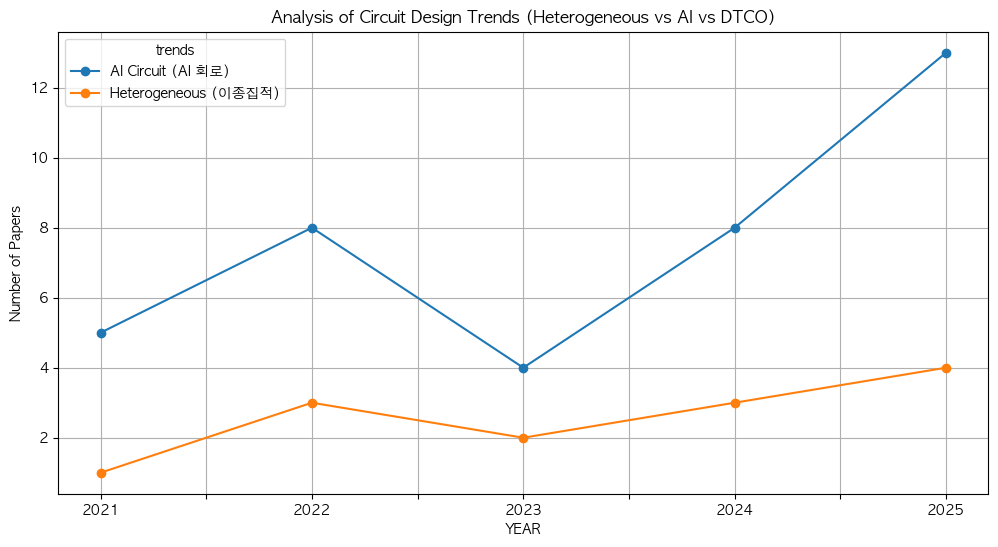

--- 트렌드별 데이터 요약 ---
trends
AI Circuit (AI 회로)      38
Heterogeneous (이종집적)    13
dtype: int64


In [10]:
#회로팀 트랜드 분석용


import matplotlib.pyplot as plt
import seaborn as sns

# 맥북(macOS) 한글 폰트 설정
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 키워드 그룹 정의
target_groups = {
    'Heterogeneous (이종집적)': ['chiplet', '3d ic', 'tsv', 'heterogeneous', 'fan out', 'interposer'],
    'AI Circuit (AI 회로)': ['pim', 'npu', 'sram based', 'neuromorphic', 'in-memory', 'accelerator'],
    'DTCO (공정/회로 최적화)': ['dtco', 'co-optimization', 'standard cell design', 'parasitic extraction']
}

# 2. 그룹별 출현 빈도 계산 함수
def check_trends(row):
    text = (str(row['NODE_TTLE']) + " " + str(row['KYWD'])).lower()
    found_groups = []
    for group_name, keywords in target_groups.items():
        if any(k in text for k in keywords):
            found_groups.append(group_name)
    return found_groups

# 3. 데이터 적용 및 연도별 집계
final_cleaned_df['trends'] = final_cleaned_df.apply(check_trends, axis=1)
trend_exploded = final_cleaned_df.explode('trends')

# 연도 추출 (PBSH 컬럼 활용)
trend_exploded['YEAR'] = trend_exploded['PBSH'].astype(str).str[:4]
trend_summary = trend_exploded.groupby(['YEAR', 'trends']).size().unstack().fillna(0)

# 4. 시각화
plt.figure(figsize=(12, 6))
trend_summary.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Analysis of Circuit Design Trends (Heterogeneous vs AI vs DTCO)')
plt.ylabel('Number of Papers')
plt.grid(True)
plt.show()

print("--- 트렌드별 데이터 요약 ---")
print(trend_summary.sum())

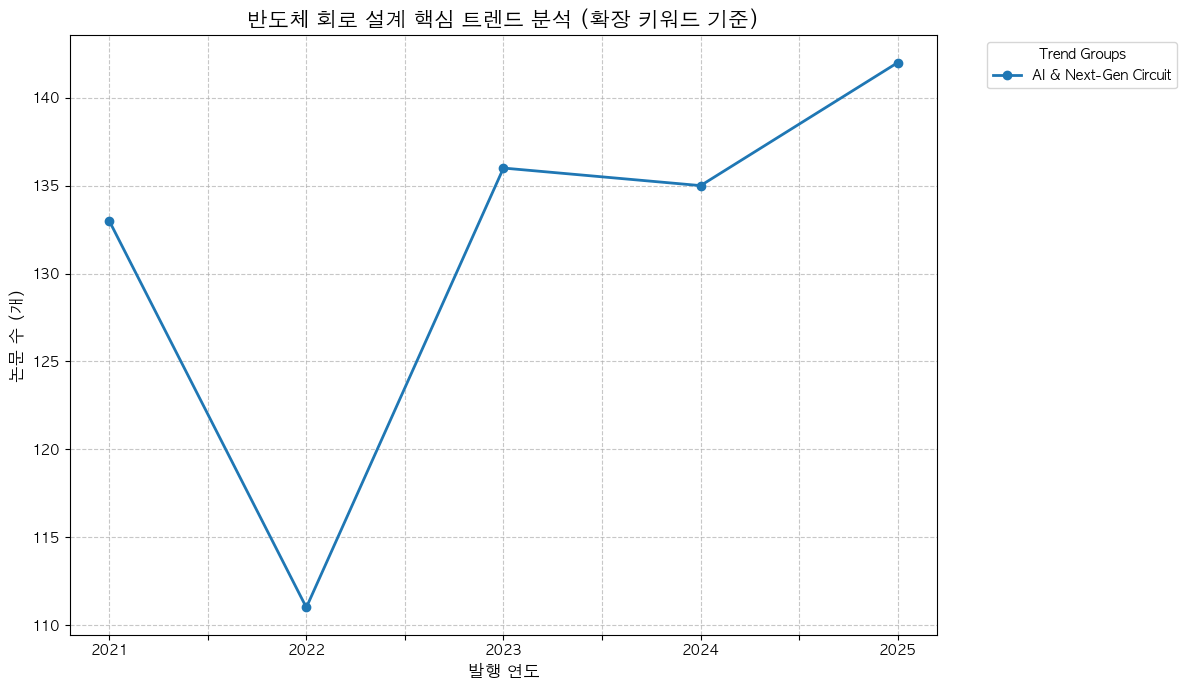

--- [확장 후] 트렌드별 데이터 요약 ---
trends_expanded
AI & Next-Gen Circuit    657
dtype: int64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 맥북 한글 폰트 설정 (이전에 깨졌다면 필수)
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

# 2. 키워드 그룹 확장 정의 (유의어 및 범용어 추가)
target_groups = {
    
    'AI & Next-Gen Circuit': [
        'ai', 'npu', 'pim', 'neural', 'intelligence', 'learning', 'accelerator', 
        'computing-in-memory', '가속기', '인공지능', '신경망', 'cim',  'package', '3d', 'stack', 'tsv', 'chiplet', 'heterogeneous', 
        'interposer', 'fan-out', 'hybrid bonding', '적층', '패키징'
    ]
    
}

# 3. 트렌드 분류 함수 (더 유연하게 검색)
def check_trends_expanded(row):
    # 제목(NODE_TTLE)과 키워드(KYWD)를 합쳐서 소문자로 변환 후 검색
    content = (str(row['NODE_TTLE']) + " " + str(row['KYWD'])).lower()
    found_groups = []
    for group_name, keywords in target_groups.items():
        if any(k in content for k in keywords):
            found_groups.append(group_name)
    return found_groups

# 4. 데이터 적용
final_cleaned_df['trends_expanded'] = final_cleaned_df.apply(check_trends_expanded, axis=1)
trend_exploded = final_cleaned_df.explode('trends_expanded')

# 데이터가 없는 행(NaN) 제거
trend_exploded = trend_exploded.dropna(subset=['trends_expanded'])

# 5. 연도별 집계 (PBSH 컬럼에서 연도 4자리 추출)
trend_exploded['YEAR'] = trend_exploded['PBSH'].astype(str).str[:4]
# 최근 데이터 위주로 보기 위해 2010년 이후 데이터만 필터링 (선택사항)
trend_exploded = trend_exploded[trend_exploded['YEAR'].astype(int) >= 2015]

trend_summary = trend_exploded.groupby(['YEAR', 'trends_expanded']).size().unstack().fillna(0)

# 6. 시각화
if not trend_summary.empty:
    plt.figure(figsize=(12, 7))
    trend_summary.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())
    plt.title('반도체 회로 설계 핵심 트렌드 분석 (확장 키워드 기준)', fontsize=15)
    plt.ylabel('논문 수 (개)', fontsize=12)
    plt.xlabel('발행 연도', fontsize=12)
    plt.legend(title='Trend Groups', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("--- [확장 후] 트렌드별 데이터 요약 ---")
    print(trend_summary.sum())
else:
    print("검색된 데이터가 없습니다. 키워드를 다시 확인해주세요.")